In [46]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import gaussian_kde
import time

In [47]:
plt.rc('text', usetex=False)
plt.rc('font', family='serif')

## MODELO DE KURAMOTO

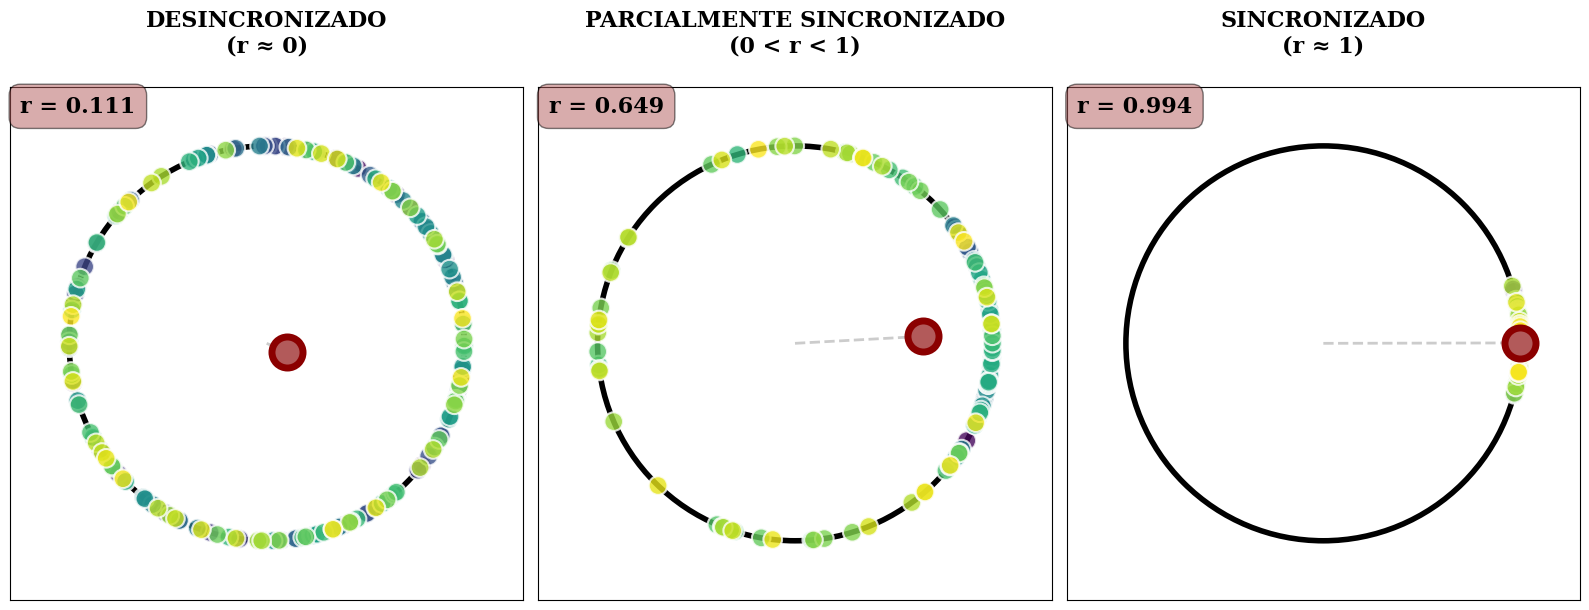

<Figure size 640x480 with 0 Axes>

In [48]:
# Configuración
N = 200
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))
axes = [ax1, ax2, ax3]
titles = ['DESINCRONIZADO\n(r ≈ 0)', 'PARCIALMENTE SINCRONIZADO\n(0 < r < 1)', 'SINCRONIZADO\n(r ≈ 1)']

colors_osc = plt.cm.viridis(np.linspace(0, 1, N))

for i, (ax, title) in enumerate(zip(axes, titles)):
    # Generar fases
    if i == 0:  # Desincronizado
        theta = np.random.uniform(0, 2*np.pi, N)
    elif i == 1:  # Parcialmente sincronizado
        theta_cluster = np.random.normal(0, 0.3, int(0.65*N))
        theta_noise = np.random.uniform(0, 2*np.pi, N - len(theta_cluster))
        theta = np.concatenate([theta_cluster, theta_noise])
    else:  # Sincronizado
        theta = np.random.normal(0, 0.1, N)

    # Centro de sincronización Z
    Z = np.mean(np.exp(1j * theta))
    r = np.abs(Z)

    # Posiciones osciladores
    x = np.real(np.exp(1j * theta))
    y = np.imag(np.exp(1j * theta))

    # 🔵 PUNTOS OSCILADORES (pequeños colores)
    ax.scatter(x, y, c=colors_osc, s=180, alpha=0.8, edgecolors='white', linewidth=1.5, zorder=5)

    # 🔴 CÍRCULO ROJO GRANDE = CENTRO SINCRO (reemplaza estrella)
    Z_x, Z_y = np.real(Z), np.imag(Z)
    ax.scatter(Z_x, Z_y, s=500, c='#B25A5A', marker='o',
               edgecolors='darkred', linewidth=5, zorder=10, alpha=1.0)

    # Círculo unitario
    circle = plt.Circle((0, 0), 1, fill=False, color='black', linewidth=4)
    ax.add_patch(circle)

    # Línea sutil origen → Z
    ax.plot([0, Z_x], [0, Z_y], 'gray', alpha=0.4, linewidth=2, linestyle='--')

    # Formato
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=25)

    # Texto r
    ax.text(0.02, 0.95, f'r = {r:.3f}', transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#B25A5A', alpha=0.5),
            fontsize=16, fontweight='bold')

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

plt.savefig('kuramoto_circulo_rojo.png', dpi=300, bbox_inches='tight')

## KURAMOTO SIN DAÑO


In [49]:

def kuramoto_rhs_pure(theta, A):
    """
    Versión vectorizada de dtheta/dt = sum(Aij * sin(theta_j - theta_i))
    K = 1 y Omega = 0 implícitos.
    """
    # Diferencias de fase de todos contra todos (Matriz NxN)
    # phase_diff[i, j] = theta[j] - theta[i]
    phase_diff = theta[None, :] - theta[:, None]

    # El producto elemento a elemento (A * sin(diff)) aplica la topología
    dtheta = np.sum(A * np.sin(phase_diff), axis=1)
    return dtheta

def kuramoto_rk4_step(theta, A, dt):
    k1 = kuramoto_rhs_pure(theta, A)
    k2 = kuramoto_rhs_pure(theta + 0.5*dt*k1, A)
    k3 = kuramoto_rhs_pure(theta + 0.5*dt*k2, A)
    k4 = kuramoto_rhs_pure(theta + dt*k3, A)

    theta_new = theta + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return np.mod(theta_new, 2*np.pi)

def order_parameter(theta):
    return np.abs(np.mean(np.exp(1j*theta)))

def Simulacion_Kuramoto(N_S, N, A, T, dt):
    steps = int(T/dt)
    R_t = np.zeros((steps, N_S))
    t_0 = np.full(N_S, np.nan)
    theta_map = np.zeros((steps, N))

    for i in range(N_S):
        # Condiciones iniciales aleatorias
        theta = np.random.uniform(0, 2*np.pi, N)

        for t in range(steps):
            theta = kuramoto_rk4_step(theta, A, dt)

            # Guardamos evolución de la fase para el heatmap (solo una simulación)
            if i == 0:
                theta_map[t, :] = theta

            r = order_parameter(theta)
            R_t[t, i] = r

            # Tiempo de sincronización (umbral 0.99)
            if np.isnan(t_0[i]) and r > 0.99:
                t_0[i] = t * dt

    return R_t, theta_map, t_0


## RUEDA

In [50]:
# --- Configuración ---
N = 20
dt = 0.01
T = 15  # Aumenté un poco el tiempo para asegurar que R llegue a 0.99
Num_Simulaciones = 1000 # Con vectorización esto corre en segundos

# Red Rueda
G_wheel = nx.wheel_graph(N)
A_wheel = nx.to_numpy_array(G_wheel)

start_time_total = time.time()
# Ejecución
R_t_wheel, theta_evo, t_0 = Simulacion_Kuramoto(Num_Simulaciones, N, A_wheel, T, dt)
R_tProm = np.mean(R_t_wheel, axis=1)
print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")




--- Tiempo total: 5.67 minutos ---


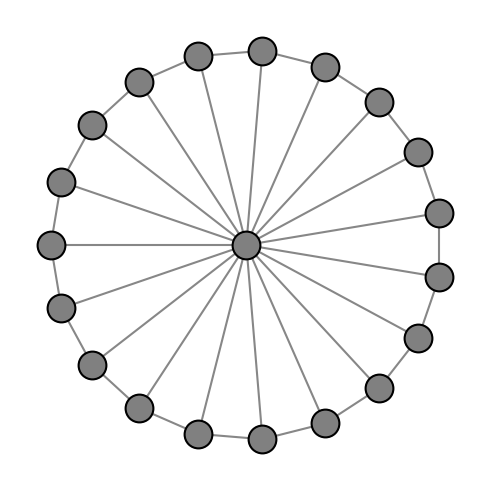

In [51]:
# --- GRÁFICA RED INTACTA WHEEL GRAPH ---

# 1. Layout shell: nodo 0 al centro, resto en círculo
pos = nx.shell_layout(G_wheel, [[0], list(range(1, N))])

# 2. Enlaces
edges = list(G_wheel.edges())

# 3. Dibujar
fig, ax = plt.subplots(figsize=(5, 5))

nx.draw_networkx_nodes(G_wheel, pos, ax=ax, node_size=400, node_color='grey',
                       edgecolors='black', linewidths=1.5)
#nx.draw_networkx_labels(G_wheel, pos, ax=ax, font_size=7, font_weight='bold')
nx.draw_networkx_edges(G_wheel, pos, ax=ax, edgelist=edges,
                       width=1.5, edge_color='dimgray', alpha=0.8)

ax.axis('off')
plt.tight_layout()
plt.show()

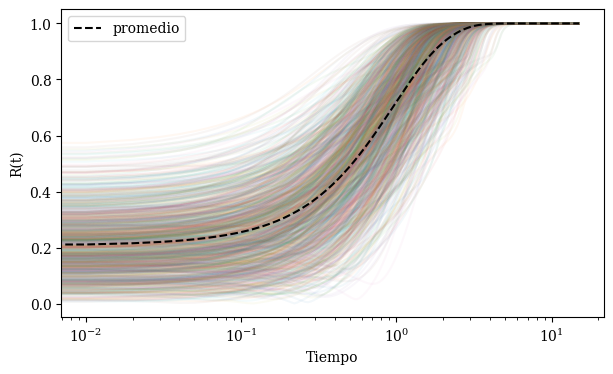

In [52]:
arrSteps=np.arange(0,T,dt)
plt.figure(figsize=(7,4))
plt.semilogx(arrSteps,R_t_wheel, alpha=0.05)
plt.semilogx(arrSteps,R_tProm,"--", color="Black", label="promedio")
plt.xlabel("Tiempo")
plt.ylabel("R(t)")
plt.legend()
plt.show()

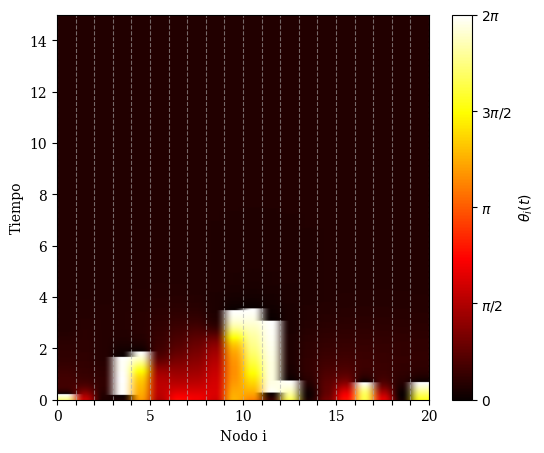

In [53]:
steps = theta_evo.shape[0]

plt.figure(figsize=(6,5))

im = plt.imshow(
    theta_evo,
    aspect="auto",
    origin="lower",
    extent=[0, N, 0, T],
    cmap="hot",
    vmin=0,
    vmax=2*np.pi
)

# Barra de color con ticks en múltiplos de pi
cbar = plt.colorbar(im, label=r"$\theta_{i}(t)$")
cbar.set_ticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
cbar.set_ticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

plt.xlabel("Nodo i")
plt.ylabel("Tiempo")

ax = plt.gca()
ax.set_xticks(np.arange(0, N+1, 1))
labels = [str(i) if i % 5 == 0 else "" for i in range(N+1)]
ax.set_xticklabels(labels)
plt.grid(True, which="major", axis="x", linestyle="--", alpha=0.6)

plt.show()

C:\Users\Kevin\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


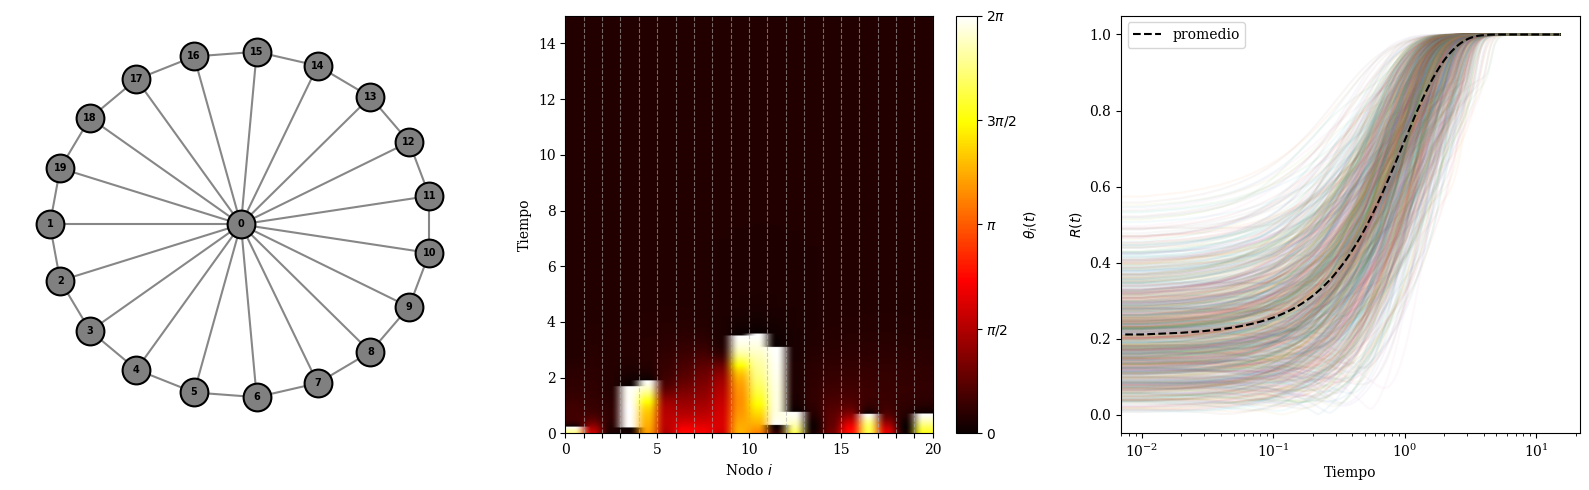

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- GRÁFICA 1: RED INTACTA ---
ax1 = axes[0]
pos = nx.shell_layout(G_wheel, [[0], list(range(1, N))])
edges = list(G_wheel.edges())
nx.draw_networkx_nodes(G_wheel, pos, ax=ax1, node_size=400, node_color='grey',
                       edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G_wheel, pos, ax=ax1, font_size=7, font_weight='bold')
nx.draw_networkx_edges(G_wheel, pos, ax=ax1, edgelist=edges,
                       width=1.5, edge_color='dimgray', alpha=0.8)
ax1.axis('off')

# --- GRÁFICA 2: EVOLUCIÓN DE FASES ---
ax2 = axes[1]
im = ax2.imshow(
    theta_evo,
    aspect="auto",
    origin="lower",
    extent=[0, N, 0, T],
    cmap="hot",
    vmin=0,
    vmax=2*np.pi
)
cbar = plt.colorbar(im, ax=ax2, label=r"$\theta_{i}(t)$")
cbar.set_ticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
cbar.set_ticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
ax2.set_xlabel("Nodo $i$")
ax2.set_ylabel("Tiempo")
ax2.set_xticks(np.arange(0, N+1, 1))
ax2.set_xticklabels([str(i) if i % 5 == 0 else "" for i in range(N+1)])
ax2.grid(True, which="major", axis="x", linestyle="--", alpha=0.6)

# --- GRÁFICA 3: PARÁMETRO DE ORDEN ---
ax3 = axes[2]
arrSteps = np.arange(0, T, dt)
ax3.semilogx(arrSteps, R_t_wheel, alpha=0.05)
ax3.semilogx(arrSteps, R_tProm, "--", color="black", label="promedio")
ax3.set_xlabel("Tiempo")
ax3.set_ylabel("$R(t)$")
ax3.legend()

plt.tight_layout()
plt.show()

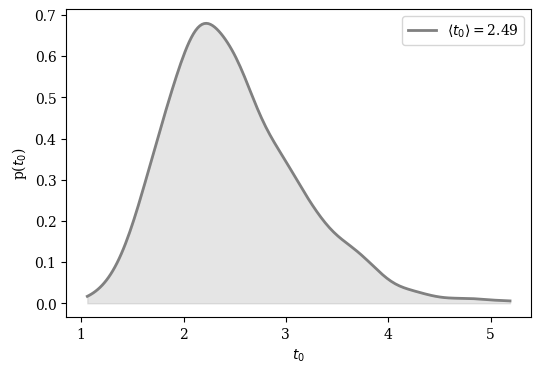

In [55]:
t0_clean = t_0[~np.isnan(t_0)]
plt.figure(figsize=(6, 4))
if len(t0_clean) > 0:
    kde = gaussian_kde(t0_clean)
    t_vals = np.linspace(t0_clean.min(), t0_clean.max(), 200)
    plt.plot(t_vals, kde(t_vals), color='grey', lw=2,label=r"$\left< t_{0}\right>=$"f"{np.mean(t0_clean):.2f}")
    plt.fill_between(t_vals, kde(t_vals), color='grey', alpha=0.2)
    plt.xlabel(r"$t_{0}$")
    plt.ylabel(r"p($t_{0}$)")
    plt.legend()

## ERDOS-RENYI

In [69]:
# --- Configuración ---
N = 20
dt = 0.01
T = 15  # Aumenté un poco el tiempo para asegurar que R llegue a 0.99
Num_Simulaciones = 1000 # Con vectorización esto corre en segundos

# Red Rueda
G_er = nx.erdos_renyi_graph(N, p=0.3) #
A_er = nx.to_numpy_array(G_er) #

start_time_total = time.time()
# Ejecución
R_t_er, theta_evo_er, t_0_er = Simulacion_Kuramoto(Num_Simulaciones, N, A_er, T, dt)#
R_tProm_er = np.mean(R_t_er, axis=1)#
print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")




--- Tiempo total: 5.24 minutos ---


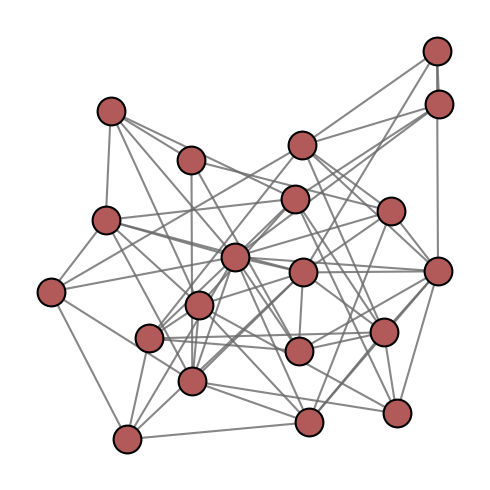

In [70]:
# --- GRÁFICA RED INTACTA WHEEL GRAPH ---

# 1. Layout shell: nodo 0 al centro, resto en círculo
pos = nx.spring_layout(G_er, seed=42)#
# 2. Enlaces
edges = list(G_er.edges())

# 3. Dibujar
fig, ax = plt.subplots(figsize=(5, 5))

nx.draw_networkx_nodes(G_er, pos, ax=ax, node_size=400, node_color='#B25A5A',
                       edgecolors='black', linewidths=1.5)
#nx.draw_networkx_labels(G_wheel, pos, ax=ax, font_size=7, font_weight='bold')
nx.draw_networkx_edges(G_er, pos, ax=ax, edgelist=edges,
                       width=1.5, edge_color='dimgray', alpha=0.8)

ax.axis('off')
plt.tight_layout()
plt.show()

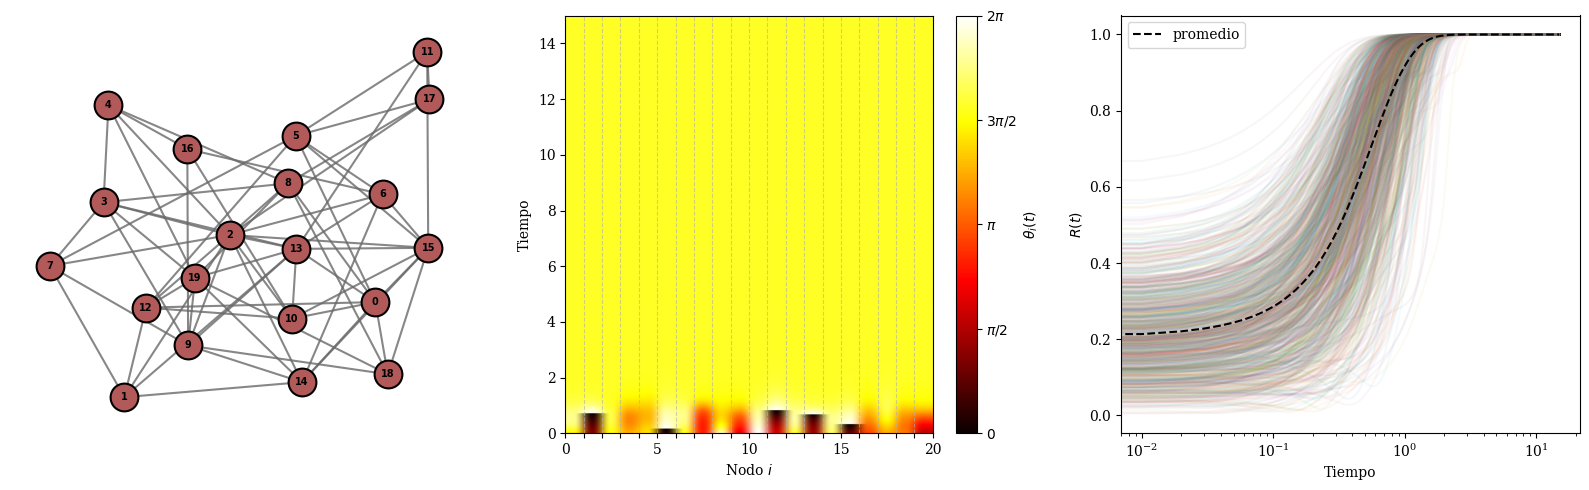

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- GRÁFICA 1: RED INTACTA ---
ax1 = axes[0]
pos = nx.spring_layout(G_er, seed=42)#
edges = list(G_er.edges())#
nx.draw_networkx_nodes(G_er, pos, ax=ax1, node_size=400, node_color='#B25A5A',#
                       edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G_er, pos, ax=ax1, font_size=7, font_weight='bold')#
nx.draw_networkx_edges(G_er, pos, ax=ax1, edgelist=edges,#
                       width=1.5, edge_color='dimgray', alpha=0.8)
ax1.axis('off')

# --- GRÁFICA 2: EVOLUCIÓN DE FASES ---
ax2 = axes[1]
im = ax2.imshow(
    theta_evo_er, #
    aspect="auto",
    origin="lower",
    extent=[0, N, 0, T],
    cmap="hot",
    vmin=0,
    vmax=2*np.pi
)
cbar = plt.colorbar(im, ax=ax2, label=r"$\theta_{i}(t)$")
cbar.set_ticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
cbar.set_ticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
ax2.set_xlabel("Nodo $i$")
ax2.set_ylabel("Tiempo")
ax2.set_xticks(np.arange(0, N+1, 1))
ax2.set_xticklabels([str(i) if i % 5 == 0 else "" for i in range(N+1)])
ax2.grid(True, which="major", axis="x", linestyle="--", alpha=0.6)

# --- GRÁFICA 3: PARÁMETRO DE ORDEN ---
ax3 = axes[2]
arrSteps = np.arange(0, T, dt)
ax3.semilogx(arrSteps, R_t_er, alpha=0.05) #
ax3.semilogx(arrSteps, R_tProm_er, "--", color="black", label="promedio")#
ax3.set_xlabel("Tiempo")
ax3.set_ylabel("$R(t)$")
ax3.legend()

plt.tight_layout()
plt.show()

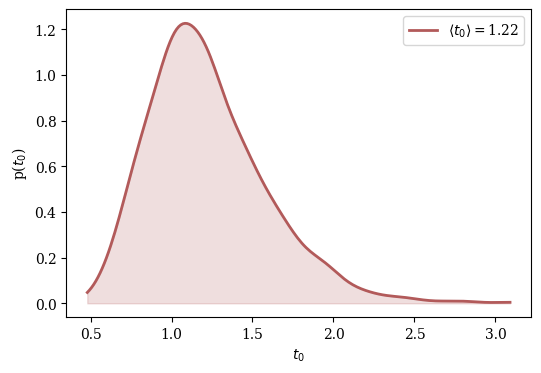

In [72]:
t0_clean = t_0_er[~np.isnan(t_0_er)]
plt.figure(figsize=(6, 4))
if len(t0_clean) > 0:
    kde = gaussian_kde(t0_clean)
    t_vals = np.linspace(t0_clean.min(), t0_clean.max(), 200)
    plt.plot(t_vals, kde(t_vals), color='#B25A5A', lw=2, label=r"$\left< t_{0}\right>=$"f"{np.mean(t0_clean):.2f}")
    plt.fill_between(t_vals, kde(t_vals), color='#B25A5A', alpha=0.2)
    plt.xlabel(r"$t_{0}$")
    plt.ylabel(r"p($t_{0}$)")
    plt.legend()

## BARABASI-ALBERT

In [60]:
# --- Configuración ---
N = 20
dt = 0.01
T = 15  # Aumenté un poco el tiempo para asegurar que R llegue a 0.99
Num_Simulaciones = 1000 # Con vectorización esto corre en segundos

# Red Rueda
G_ba = nx.barabasi_albert_graph(N, m=2) #
A_ba = nx.to_numpy_array(G_ba) #

start_time_total = time.time()
# Ejecución
R_t_ba, theta_evo_ba, t_0_ba = Simulacion_Kuramoto(Num_Simulaciones, N, A_ba, T, dt)#
R_tProm_ba = np.mean(R_t_ba, axis=1)#
print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")




--- Tiempo total: 4.42 minutos ---


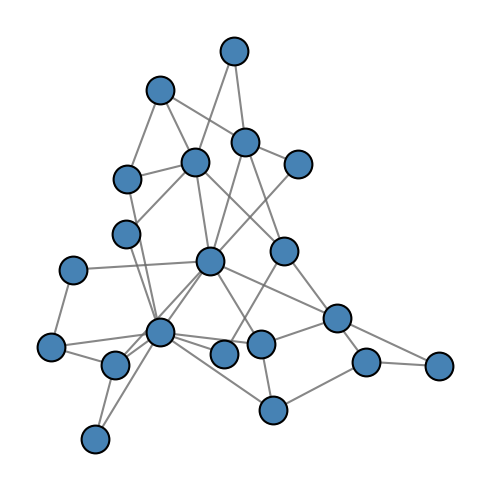

In [61]:
# --- GRÁFICA RED INTACTA WHEEL GRAPH ---

# 1. Layout shell: nodo 0 al centro, resto en círculo
pos = nx.spring_layout(G_ba, seed=42)#
# 2. Enlaces
edges = list(G_ba.edges())

# 3. Dibujar
fig, ax = plt.subplots(figsize=(5, 5))

nx.draw_networkx_nodes(G_ba, pos, ax=ax, node_size=400, node_color='#4682B4',
                       edgecolors='black', linewidths=1.5)
#nx.draw_networkx_labels(G_wheel, pos, ax=ax, font_size=7, font_weight='bold')
nx.draw_networkx_edges(G_ba, pos, ax=ax, edgelist=edges,
                       width=1.5, edge_color='dimgray', alpha=0.8)

ax.axis('off')
plt.tight_layout()
plt.show()

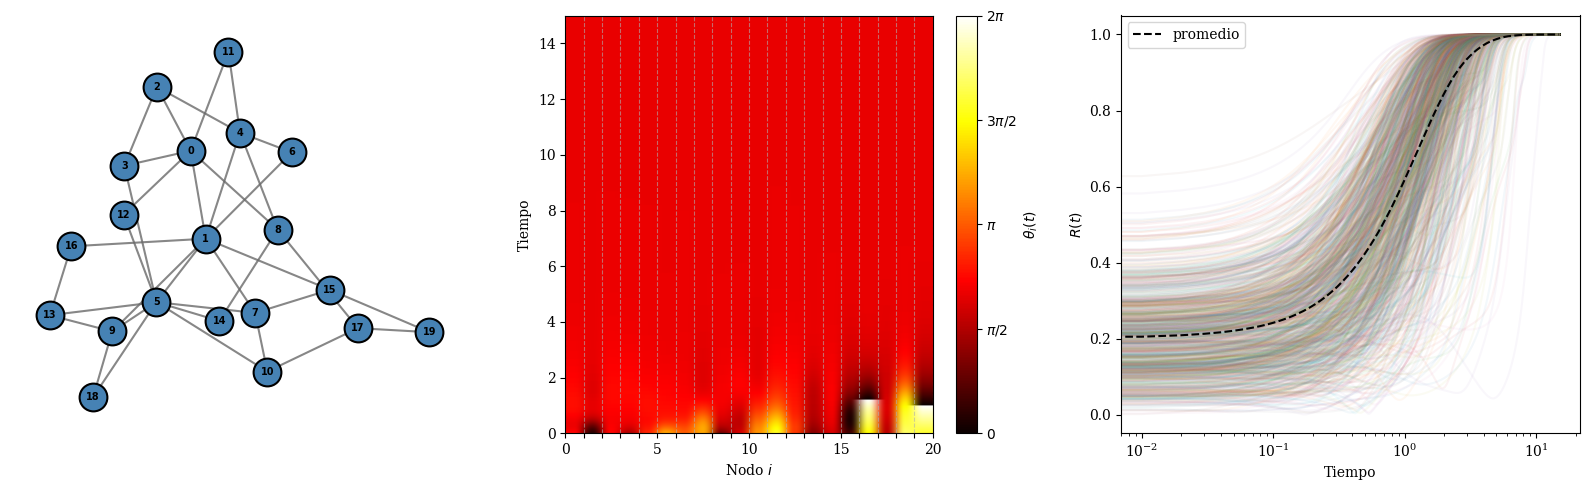

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- GRÁFICA 1: RED INTACTA ---
ax1 = axes[0]
pos = nx.spring_layout(G_ba, seed=42)#
edges = list(G_ba.edges())#
nx.draw_networkx_nodes(G_ba, pos, ax=ax1, node_size=400, node_color='#4682B4',#
                       edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G_ba, pos, ax=ax1, font_size=7, font_weight='bold')#
nx.draw_networkx_edges(G_ba, pos, ax=ax1, edgelist=edges,#
                       width=1.5, edge_color='dimgray', alpha=0.8)
ax1.axis('off')

# --- GRÁFICA 2: EVOLUCIÓN DE FASES ---
ax2 = axes[1]
im = ax2.imshow(
    theta_evo_ba, #
    aspect="auto",
    origin="lower",
    extent=[0, N, 0, T],
    cmap="hot",
    vmin=0,
    vmax=2*np.pi
)
cbar = plt.colorbar(im, ax=ax2, label=r"$\theta_{i}(t)$")
cbar.set_ticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
cbar.set_ticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
ax2.set_xlabel("Nodo $i$")
ax2.set_ylabel("Tiempo")
ax2.set_xticks(np.arange(0, N+1, 1))
ax2.set_xticklabels([str(i) if i % 5 == 0 else "" for i in range(N+1)])
ax2.grid(True, which="major", axis="x", linestyle="--", alpha=0.6)

# --- GRÁFICA 3: PARÁMETRO DE ORDEN ---
ax3 = axes[2]
arrSteps = np.arange(0, T, dt)
ax3.semilogx(arrSteps, R_t_ba, alpha=0.05) #
ax3.semilogx(arrSteps, R_tProm_ba, "--", color="black", label="promedio")#
ax3.set_xlabel("Tiempo")
ax3.set_ylabel("$R(t)$")
ax3.legend()

plt.tight_layout()
plt.show()

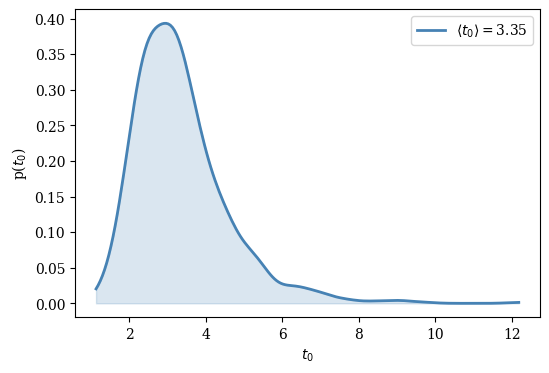

In [63]:
t0_clean = t_0_ba[~np.isnan(t_0_ba)]#
plt.figure(figsize=(6, 4))
if len(t0_clean) > 0:
    kde = gaussian_kde(t0_clean)
    t_vals = np.linspace(t0_clean.min(), t0_clean.max(), 200)
    plt.plot(t_vals, kde(t_vals), color='#4682B4', lw=2, label=r"$\left< t_{0}\right>=$"f"{np.mean(t0_clean):.2f}")
    plt.fill_between(t_vals, kde(t_vals), color='#4682B4', alpha=0.2)
    plt.xlabel(r"$t_{0}$")
    plt.ylabel(r"p($t_{0}$)")
    plt.legend()

## WATTS-STROGATZ (mundo pequeño)

In [64]:
# --- Configuración ---
N = 20
dt = 0.01
T = 15  # Aumenté un poco el tiempo para asegurar que R llegue a 0.99
Num_Simulaciones = 1000 # Con vectorización esto corre en segundos

# Red Rueda
G_ws = nx.watts_strogatz_graph(N, k=4, p=0.3) #
A_ws = nx.to_numpy_array(G_ws) #

start_time_total = time.time()
# Ejecución
R_t_ws, theta_evo_ws, t_0_ws = Simulacion_Kuramoto(Num_Simulaciones, N, A_ws, T, dt)#
R_tProm_ws = np.mean(R_t_ws, axis=1)#
print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")




--- Tiempo total: 5.27 minutos ---


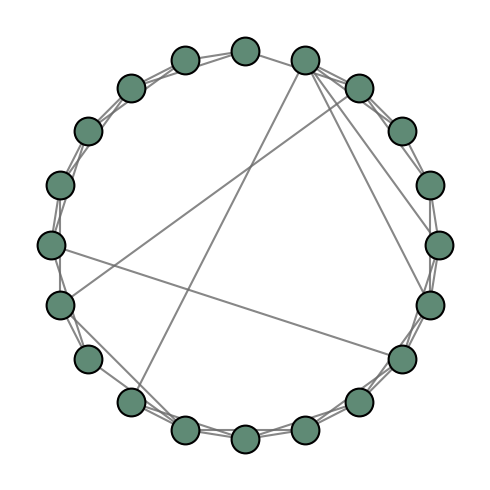

In [65]:
# --- GRÁFICA RED INTACTA WHEEL GRAPH ---

# 1. Layout shell: nodo 0 al centro, resto en círculo
pos = nx.circular_layout(G_ws)#
# 2. Enlaces
edges = list(G_ws.edges())

# 3. Dibujar
fig, ax = plt.subplots(figsize=(5, 5))

nx.draw_networkx_nodes(G_ws, pos, ax=ax, node_size=400, node_color='#5F8A75',
                       edgecolors='black', linewidths=1.5)
#nx.draw_networkx_labels(G_wheel, pos, ax=ax, font_size=7, font_weight='bold')
nx.draw_networkx_edges(G_ws, pos, ax=ax, edgelist=edges,
                       width=1.5, edge_color='dimgray', alpha=0.8)

ax.axis('off')
plt.tight_layout()
plt.show()

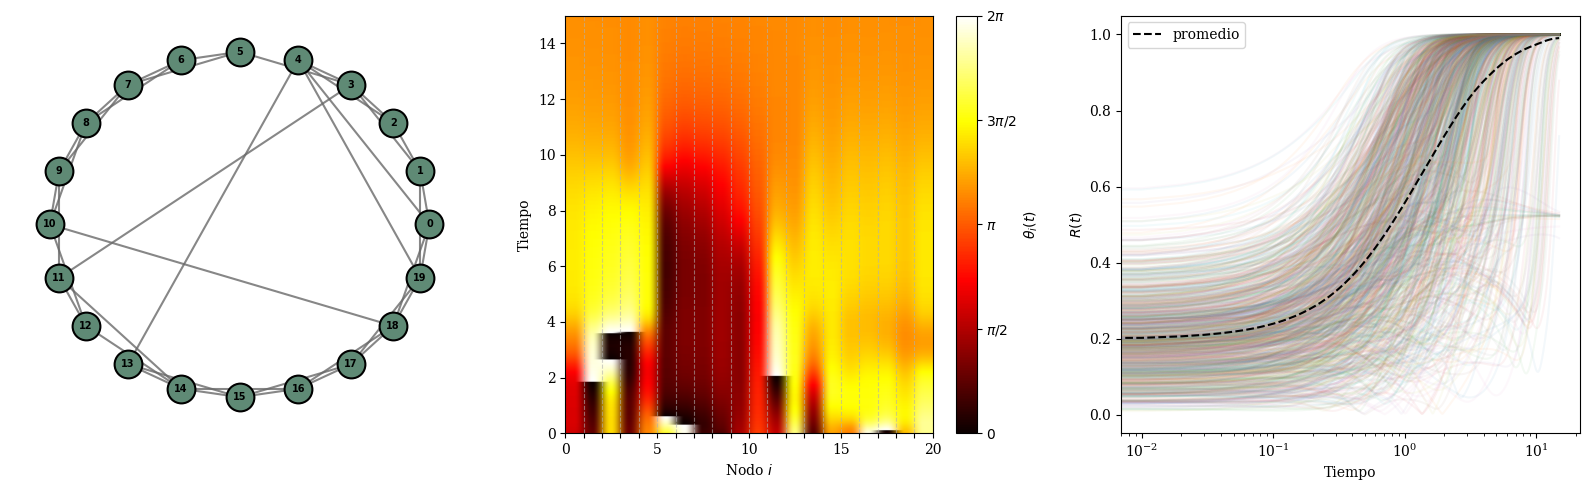

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- GRÁFICA 1: RED INTACTA ---
ax1 = axes[0]
pos = nx.circular_layout(G_ws)#
edges = list(G_ws.edges())#
nx.draw_networkx_nodes(G_ws, pos, ax=ax1, node_size=400, node_color='#5F8A75',#
                       edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G_ws, pos, ax=ax1, font_size=7, font_weight='bold')#
nx.draw_networkx_edges(G_ws, pos, ax=ax1, edgelist=edges,#
                       width=1.5, edge_color='dimgray', alpha=0.8)
ax1.axis('off')

# --- GRÁFICA 2: EVOLUCIÓN DE FASES ---
ax2 = axes[1]
im = ax2.imshow(
    theta_evo_ws, #
    aspect="auto",
    origin="lower",
    extent=[0, N, 0, T],
    cmap="hot",
    vmin=0,
    vmax=2*np.pi
)
cbar = plt.colorbar(im, ax=ax2, label=r"$\theta_{i}(t)$")
cbar.set_ticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
cbar.set_ticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
ax2.set_xlabel("Nodo $i$")
ax2.set_ylabel("Tiempo")
ax2.set_xticks(np.arange(0, N+1, 1))
ax2.set_xticklabels([str(i) if i % 5 == 0 else "" for i in range(N+1)])
ax2.grid(True, which="major", axis="x", linestyle="--", alpha=0.6)

# --- GRÁFICA 3: PARÁMETRO DE ORDEN ---
ax3 = axes[2]
arrSteps = np.arange(0, T, dt)
ax3.semilogx(arrSteps, R_t_ws, alpha=0.05) #
ax3.semilogx(arrSteps, R_tProm_ws, "--", color="black", label="promedio")#
ax3.set_xlabel("Tiempo")
ax3.set_ylabel("$R(t)$")
ax3.legend()

plt.tight_layout()
plt.show()

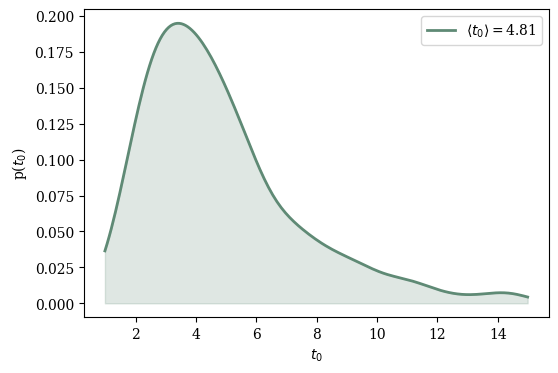

In [67]:
t0_clean = t_0_ws[~np.isnan(t_0_ws)]#
plt.figure(figsize=(6, 4))
if len(t0_clean) > 0:
    kde = gaussian_kde(t0_clean)
    t_vals = np.linspace(t0_clean.min(), t0_clean.max(), 200)
    plt.plot(t_vals, kde(t_vals), color='#5F8A75', lw=2, label=r"$\left< t_{0}\right>=$"f"{np.mean(t0_clean):.2f}")
    plt.fill_between(t_vals, kde(t_vals), color='#5F8A75', alpha=0.2)
    plt.xlabel(r"$t_{0}$")
    plt.ylabel(r"p($t_{0}$)")
    plt.legend()

## FRACTAL

In [81]:
# --- Configuración ---
G_fractal = nx.balanced_tree(r=4, h=2)
G_fractal.remove_node(20)
A_fractal = nx.to_numpy_array(G_fractal)
N = G_fractal.number_of_nodes()
print(f"Nodos: {N}")

dt = 0.01
T = 15
Num_Simulaciones = 1000

start_time_total = time.time()
R_t_fractal, theta_evo_fractal, t_0_fractal = Simulacion_Kuramoto(
    Num_Simulaciones, N, A_fractal, T, dt
)
R_tProm_fractal = np.mean(R_t_fractal, axis=1)
print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")

Nodos: 20

--- Tiempo total: 4.73 minutos ---


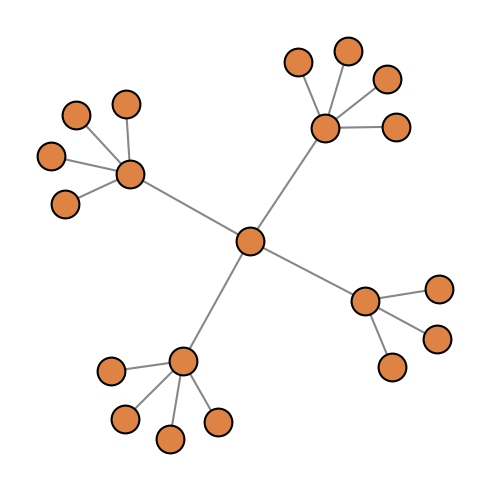

In [83]:
# --- GRÁFICA RED FRACTAL ---

pos = nx.spring_layout(G_fractal, seed=42)
edges = list(G_fractal.edges())

fig, ax = plt.subplots(figsize=(5, 5))

nx.draw_networkx_nodes(G_fractal, pos, ax=ax, node_size=400, node_color="#DF8345",
                       edgecolors='black', linewidths=1.5)
nx.draw_networkx_edges(G_fractal, pos, ax=ax, edgelist=edges,
                       width=1.5, edge_color='dimgray', alpha=0.8)

ax.axis('off')
plt.tight_layout()
plt.show()

C:\Users\Kevin\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


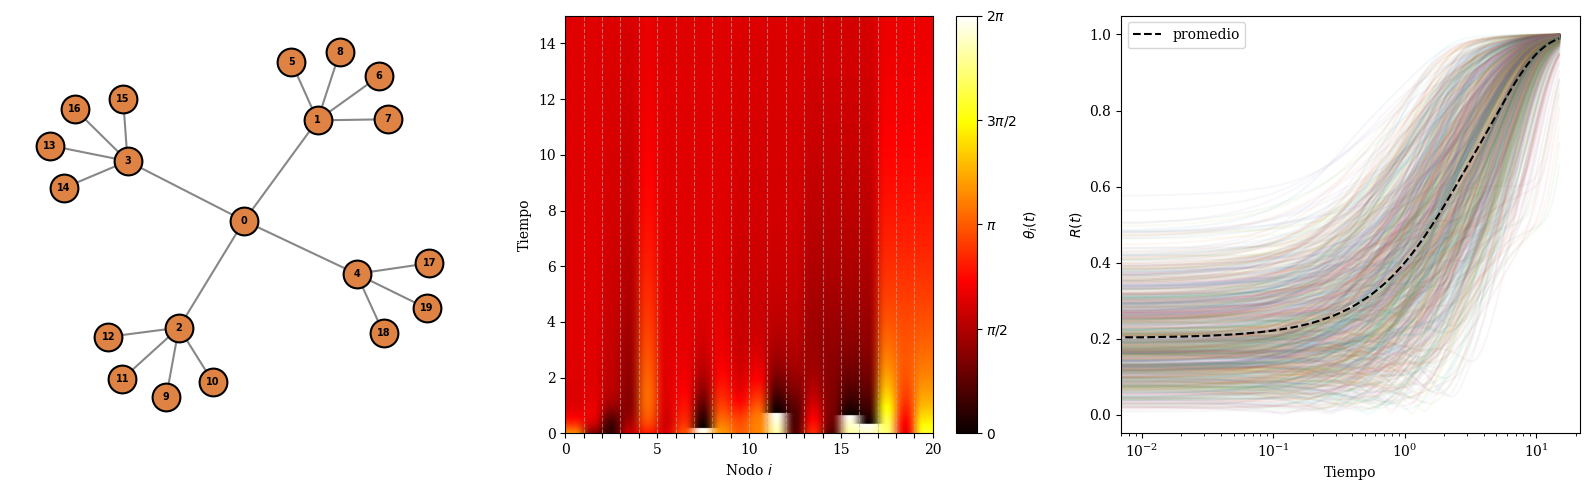

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- GRÁFICA 1: RED INTACTA ---
ax1 = axes[0]
pos = nx.spring_layout(G_fractal, seed=42)
edges = list(G_fractal.edges())#
nx.draw_networkx_nodes(G_fractal, pos, ax=ax1, node_size=400, node_color="#DF8345",#
                       edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G_fractal, pos, ax=ax1, font_size=7, font_weight='bold')#
nx.draw_networkx_edges(G_fractal, pos, ax=ax1, edgelist=edges,#
                       width=1.5, edge_color='dimgray', alpha=0.8)
ax1.axis('off')

# --- GRÁFICA 2: EVOLUCIÓN DE FASES ---
ax2 = axes[1]
im = ax2.imshow(
    theta_evo_fractal, #
    aspect="auto",
    origin="lower",
    extent=[0, N, 0, T],
    cmap="hot",
    vmin=0,
    vmax=2*np.pi
)
cbar = plt.colorbar(im, ax=ax2, label=r"$\theta_{i}(t)$")
cbar.set_ticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
cbar.set_ticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
ax2.set_xlabel("Nodo $i$")
ax2.set_ylabel("Tiempo")
ax2.set_xticks(np.arange(0, N+1, 1))
ax2.set_xticklabels([str(i) if i % 5 == 0 else "" for i in range(N+1)])
ax2.grid(True, which="major", axis="x", linestyle="--", alpha=0.6)

# --- GRÁFICA 3: PARÁMETRO DE ORDEN ---
ax3 = axes[2]
arrSteps = np.arange(0, T, dt)
ax3.semilogx(arrSteps, R_t_fractal, alpha=0.05) #
ax3.semilogx(arrSteps, R_tProm_fractal, "--", color="black", label="promedio")#
ax3.set_xlabel("Tiempo")
ax3.set_ylabel("$R(t)$")
ax3.legend()

plt.tight_layout()
plt.show()

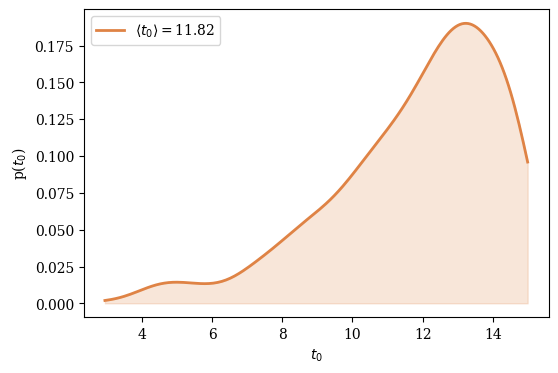

In [92]:
t0_clean = t_0_fractal[~np.isnan(t_0_fractal)]#
plt.figure(figsize=(6, 4))
if len(t0_clean) > 0:
    kde = gaussian_kde(t0_clean)
    t_vals = np.linspace(t0_clean.min(), t0_clean.max(), 200)
    plt.plot(t_vals, kde(t_vals), color='#DF8345', lw=2, label=r"$\left< t_{0}\right>=$"f"{np.mean(t0_clean):.2f}")
    plt.fill_between(t_vals, kde(t_vals), color='#DF8345', alpha=0.2)
    plt.xlabel(r"$t_{0}$")
    plt.ylabel(r"p($t_{0}$)")
    plt.legend()

## GRAFICAS

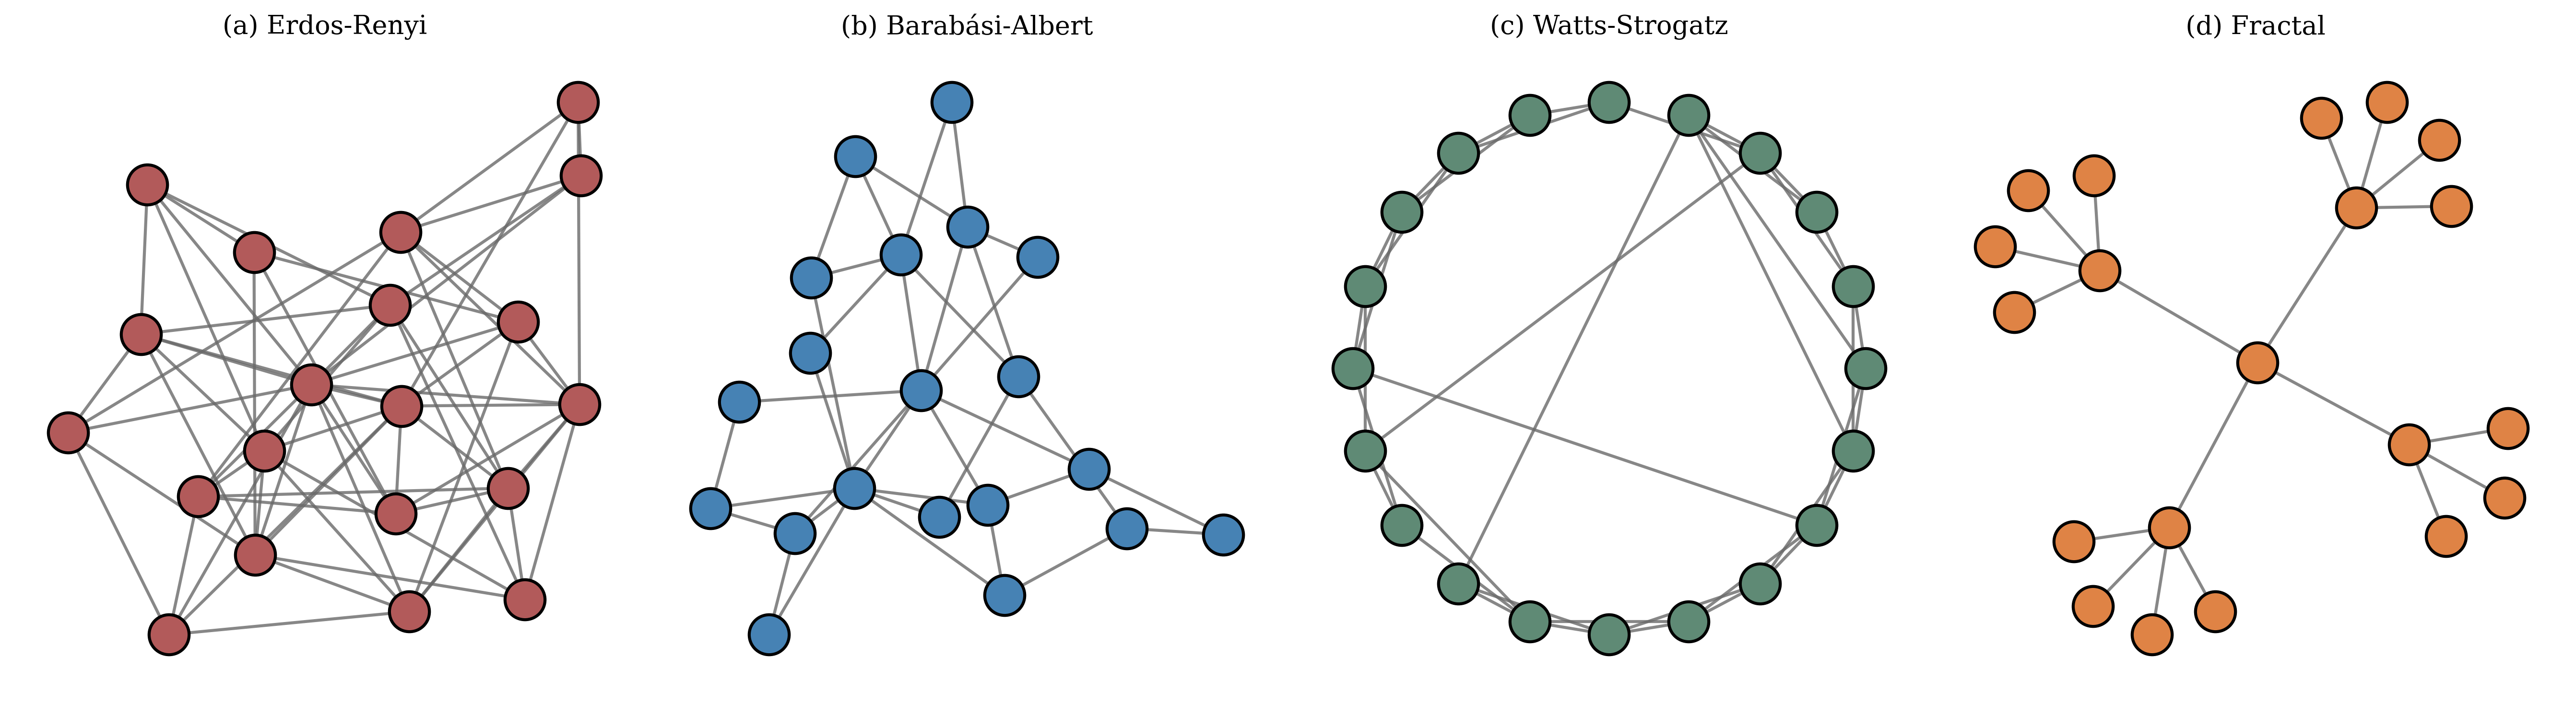

In [99]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), dpi=300)

redes = [
    (G_er,    nx.spring_layout(G_er,   seed=42),                  '#B25A5A', '(a) Erdos-Renyi'),
    (G_ba,    nx.spring_layout(G_ba,   seed=42),                  '#4682B4', '(b) Barabási-Albert'),
    (G_ws,    nx.circular_layout(G_ws),                           '#5F8A75', '(c) Watts-Strogatz'),
    (G_fractal, nx.spring_layout(G_fractal, seed=42), '#DF8345',    ' (d) Fractal'),
]

for ax, (G, pos, color, titulo) in zip(axes, redes):
    edges = list(G.edges())
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=400, node_color=color,
                           edgecolors='black', linewidths=1.5)
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges,
                           width=1.5, edge_color='dimgray', alpha=0.8)
    ax.set_title(titulo, fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

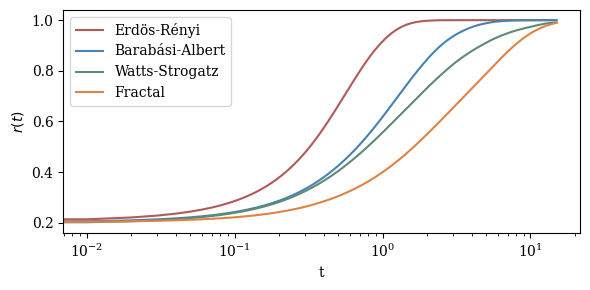

In [100]:
# --- GRÁFICA 3: PARÁMETRO DE ORDEN ---
arrSteps = np.arange(0, T, dt)
plt.figure(figsize=(6, 3))
plt.semilogx(arrSteps, R_tProm_er, color='#B25A5A', label="Erdös-Rényi")#
plt.semilogx(arrSteps, R_tProm_ba, color='#4682B4', label="Barabási-Albert")#
plt.semilogx(arrSteps, R_tProm_ws, color='#5F8A75', label="Watts-Strogatz")#
plt.semilogx(arrSteps, R_tProm_fractal, color='#DF8345', label="Fractal")#

plt.xlabel("t")
plt.ylabel(r"$r(t)$")
plt.legend()

plt.tight_layout()
plt.show()